# 5.2.5  传递参数时的序列解包

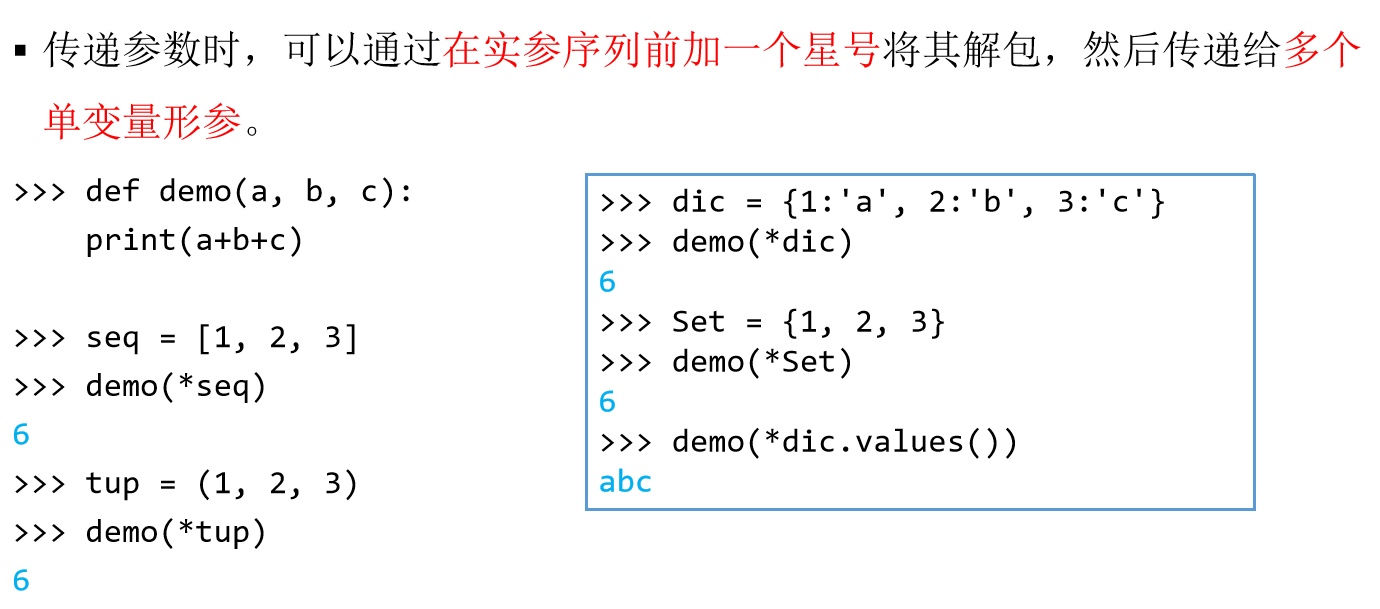

# 实参是字典时候，一个星号是对键进行解包并赋值

In [38]:
def demo(a, b, c):
    print(a+b+c)


dic = {1:'a', 2:'b', 3:'c'}
demo(*dic) 

6


In [39]:
demo(*dic.keys())

6


In [40]:
demo(*dic.values())

abc


In [4]:
def demo(a, b, c):
    print(a+b+c)
dic = {'a':1, 'b':2, 'c':3}

demo(*dic)

abc


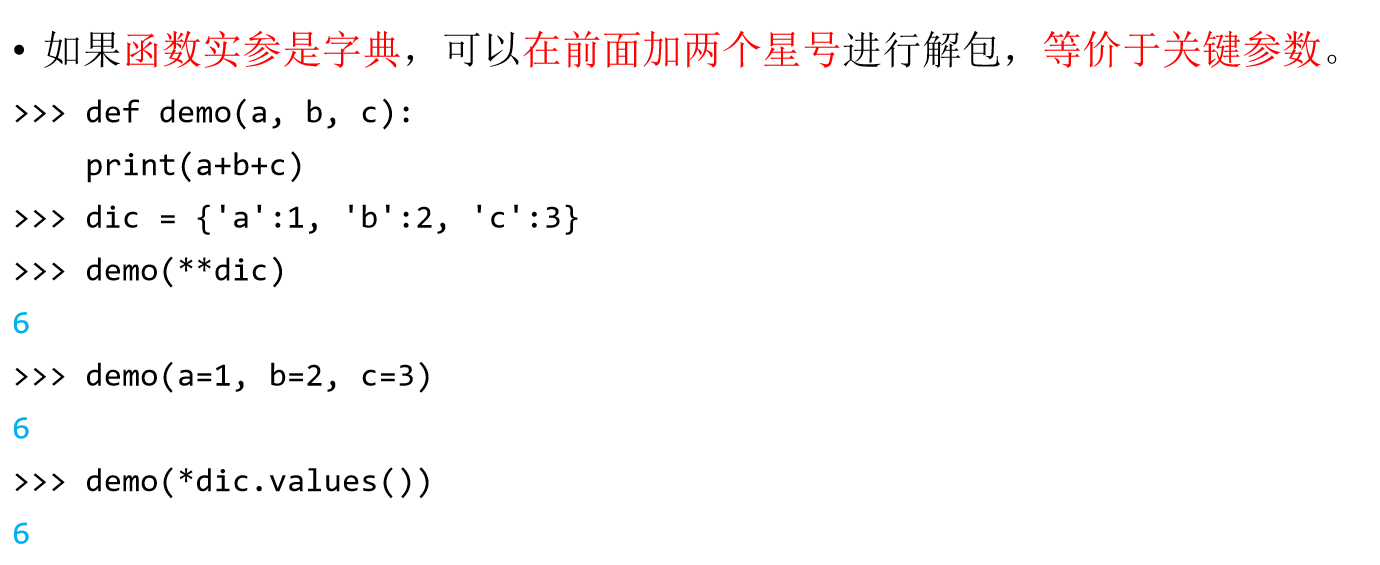

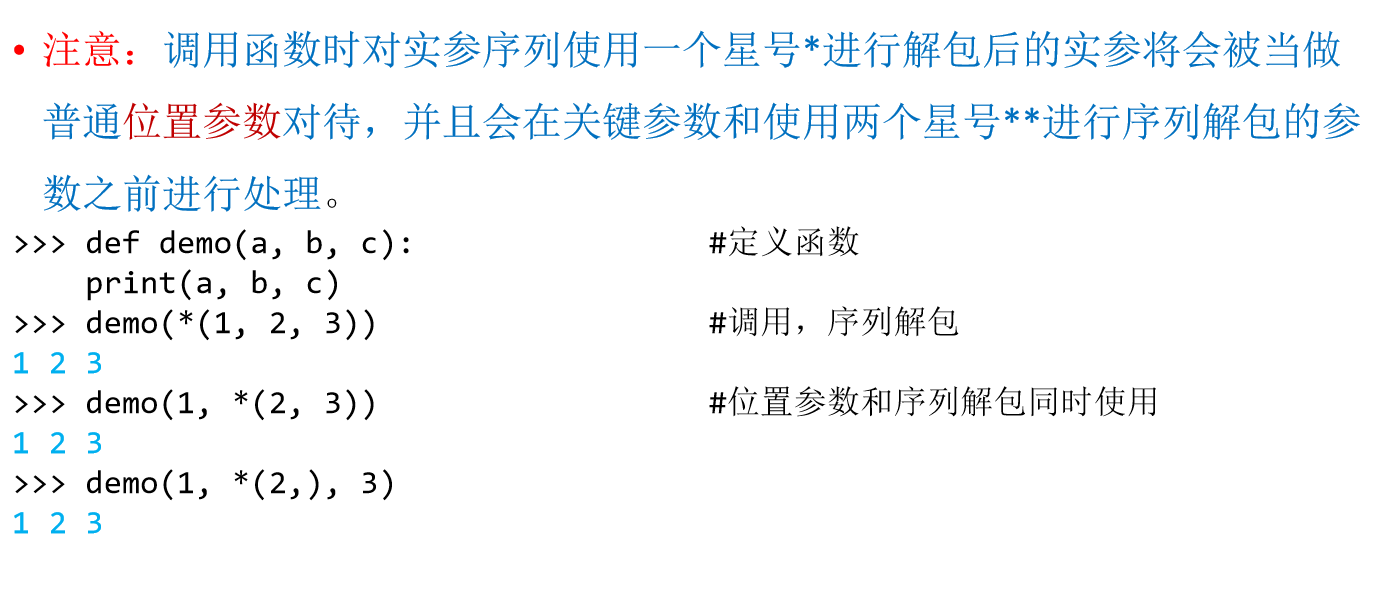

In [46]:
def demo(a, b, c):
    print(a+b+c)
demo(1, *(2,), 3)         #序列解包相当于位置参数，优先处理

6


In [47]:
demo(b=1, *(2, 3))

TypeError: demo() got multiple values for argument 'b'

In [8]:
demo(c=1, *(2, 3))

6


In [45]:
demo(**{'c':1, 'b':2}, *(3,)) #序列解包不能在关键参数解包之后

SyntaxError: iterable argument unpacking follows keyword argument unpacking (<ipython-input-45-81aeb021c341>, line 1)

In [49]:
def demo(a, b, c):
    print(a+b+c)
demo(*(3,), **{'a':1, 'b':2})

TypeError: demo() got multiple values for argument 'a'

In [11]:
demo(*(3,), **{'c':1, 'b':2})

6


# 5.3  变量作用域


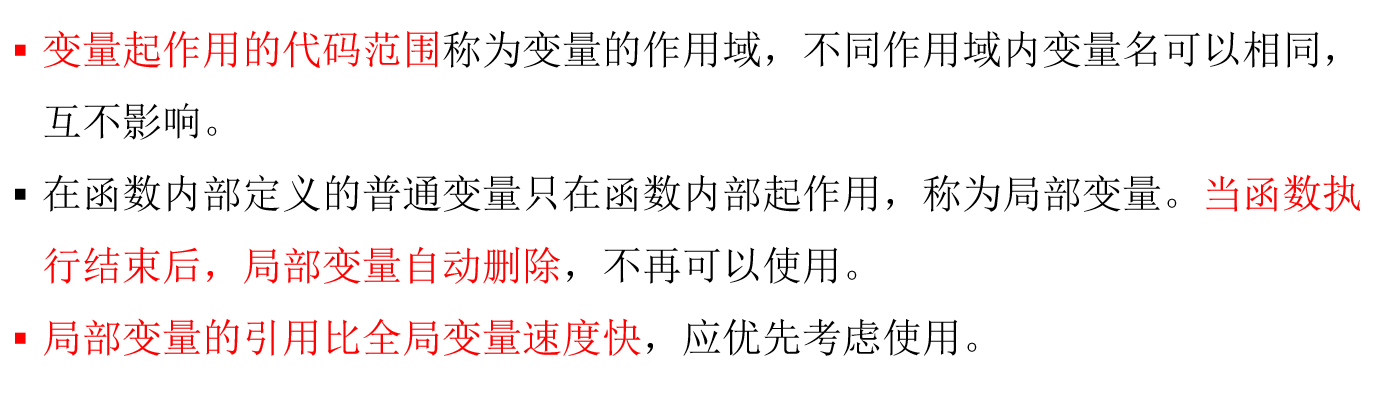

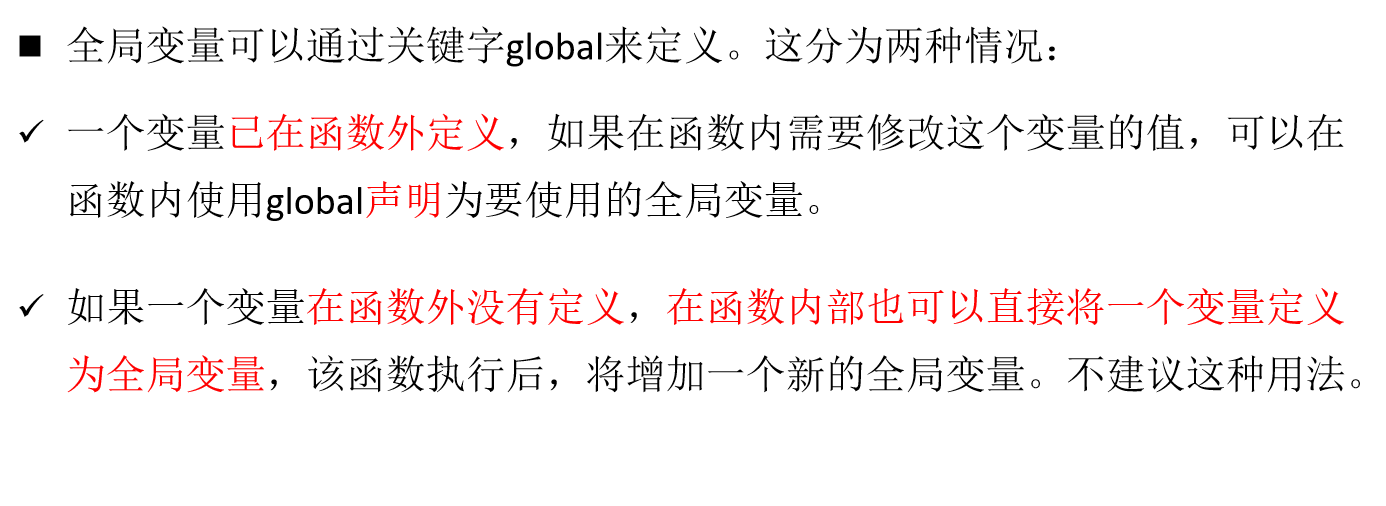

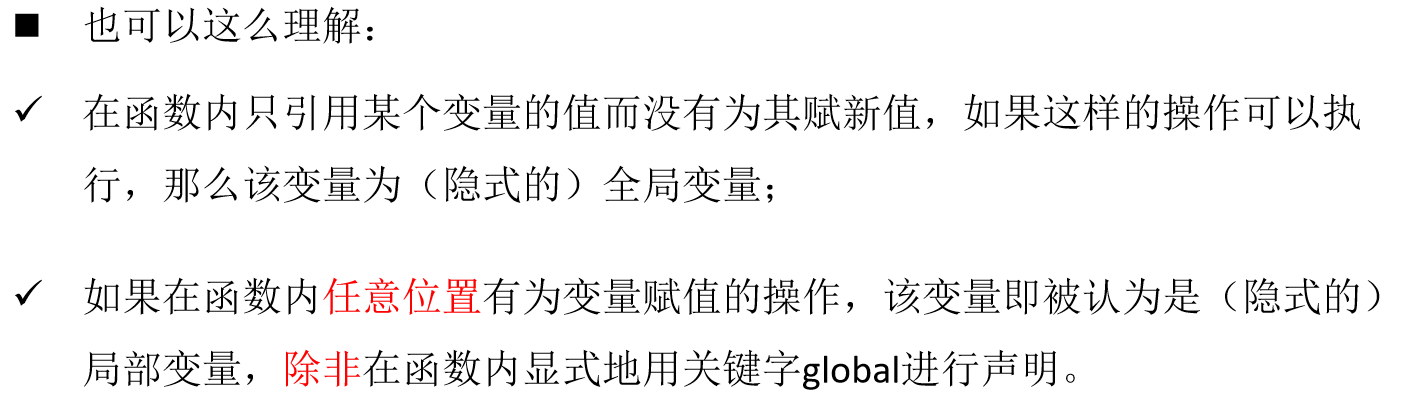

In [63]:
def demo():
    #global x
    x = 3
    y = 4
    #print(x,y)
    
demo()

In [64]:
x

<generator object f at 0x000001662608EF90>

In [58]:
y

NameError: name 'y' is not defined

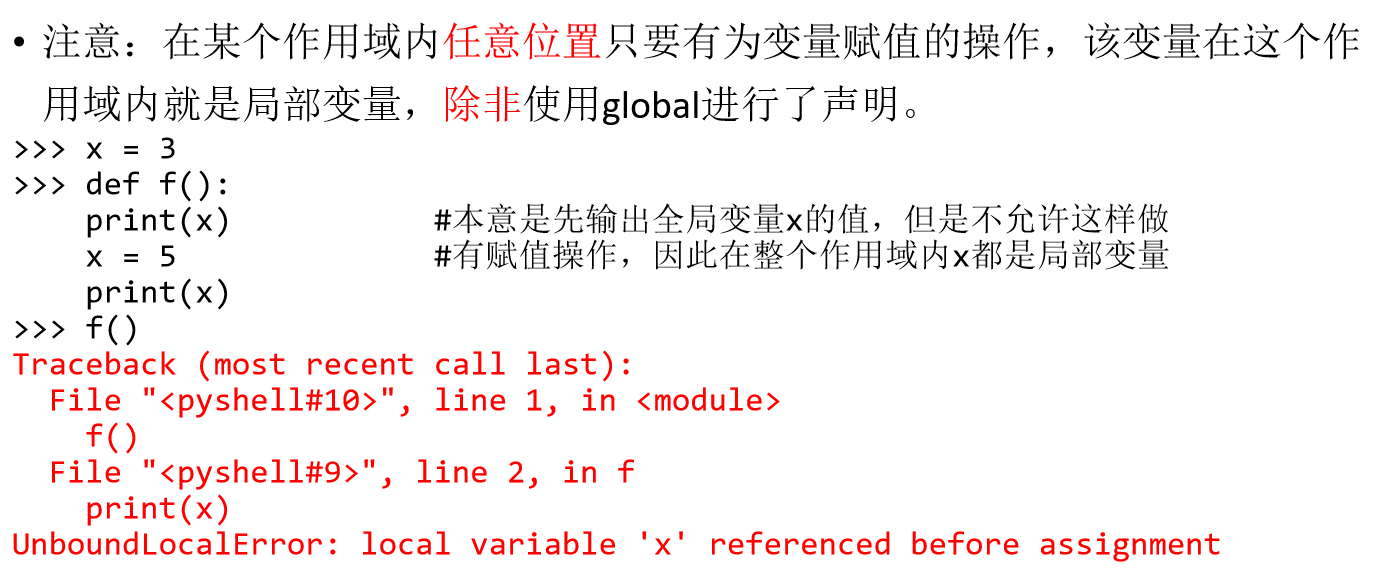

In [7]:
x = 3
def f():
    print(x)           #本意是先输出全局变量x的值，但是不允许这样做
    x = 5              #有赋值操作，因此在整个作用域内x都是局部变量
    print(x)
f()

3
5


In [8]:
x = 3
def f():
    print(x)           
f()

3


In [19]:
x = 3
def f():
    global x
    print(x)           
    x = 5              
    print(x)
f()

3
5


In [20]:
x

5

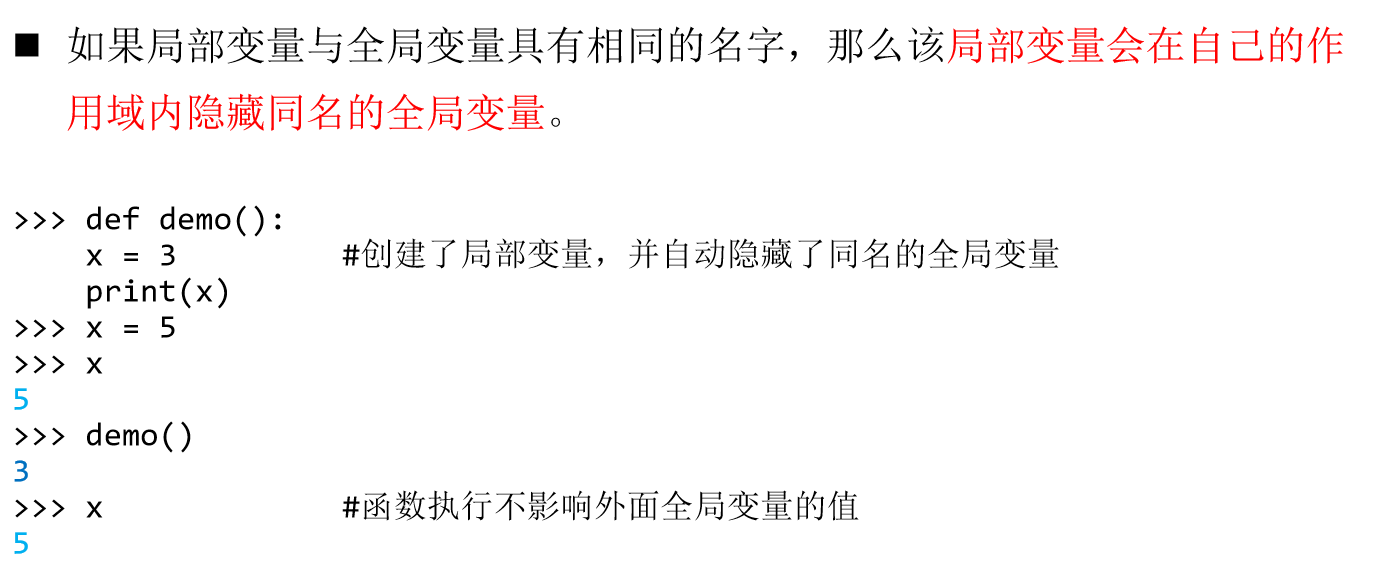

In [52]:
def demo():
    x = 3         #创建了局部变量，并自动隐藏了同名的全局变量	
    print(x)

x=5
demo()

3


In [53]:
x

5

# 5.4  lambda表达式


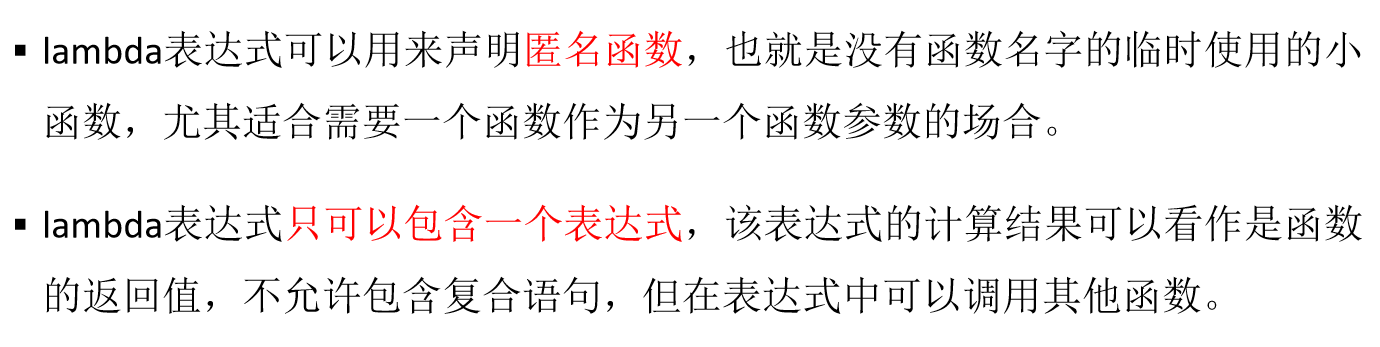

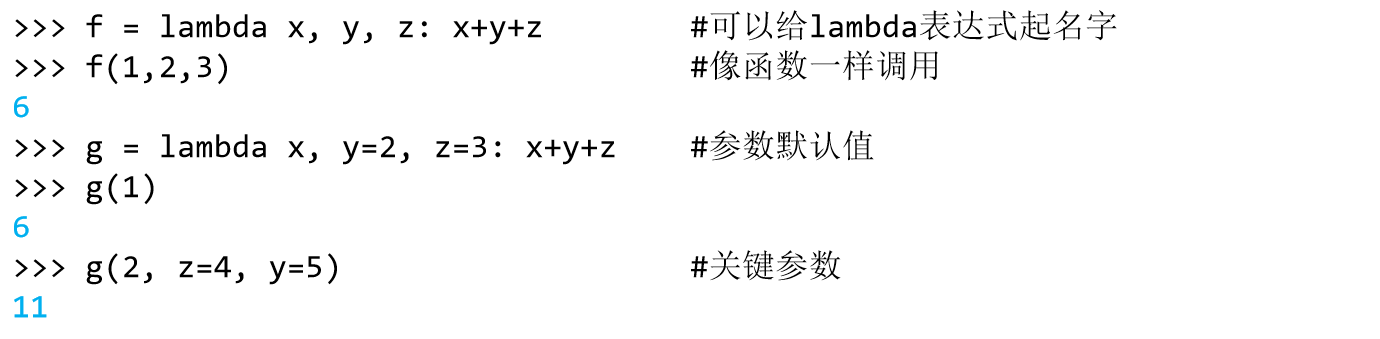

In [2]:
L = [(lambda x: x**2),
         (lambda x: x**3),
         (lambda x: x**4)]
print(L[0](2),L[1](2),L[2](2),sep=';')

4;8;16


In [55]:
D = {'f1':(lambda:2+3),
         'f2':(lambda:2*3),         
         'f3':(lambda:2**3)}
print(D['f1'](), D['f2'](), D['f3']())


5 6 8


In [56]:
L = [1,2,3,4,5]
print(list(map(lambda x: x+10, L))) 

[11, 12, 13, 14, 15]


In [21]:
def demo(n):
    return n*n

a_list = [1,2,3,4,5] 
list(map(lambda x: x+demo(x), a_list)) 

[2, 6, 12, 20, 30]

In [22]:
import random
x = [[random.randint(1,10) for j in range(5)] for i in range(5)]
                                    #使用列表推导式创建列表
                                    #包含5个子列表的列表
                                    #每个子列表中包含5个1到10之间的随机数
for item in x:
    print(item) 

[10, 9, 2, 6, 6]
[4, 9, 9, 4, 4]
[1, 2, 9, 10, 3]
[4, 8, 3, 9, 3]
[3, 6, 3, 9, 4]


In [23]:
y = sorted(x, key=lambda item: (item[1], item[4]))#按子列表中第2个元素升序、第5个元素升序排序
for item in y:
    print(item)

[1, 2, 9, 10, 3]
[3, 6, 3, 9, 4]
[4, 8, 3, 9, 3]
[4, 9, 9, 4, 4]
[10, 9, 2, 6, 6]


## 在循环结构中定义的lambda表达式或函数在循环结构之外使用时，要注意变量作用域带来的问题

In [17]:
r = []
for x in range(10):
    r.append(lambda: x**2)

r[1]()# 所有的 lambda 函数都是在循环结束后才被调用的。
      #lambda 函数中引用的变量 x 是自由变量，
      #它会在函数被调用时才会查找其值。

81

In [16]:
r = []
for x in range(10):
    r.append(lambda n=x: n**2)#默认参数捕获当前 x 的值

r[1]()# x=9局部变量

1

# 5.5  生成器函数设计要点


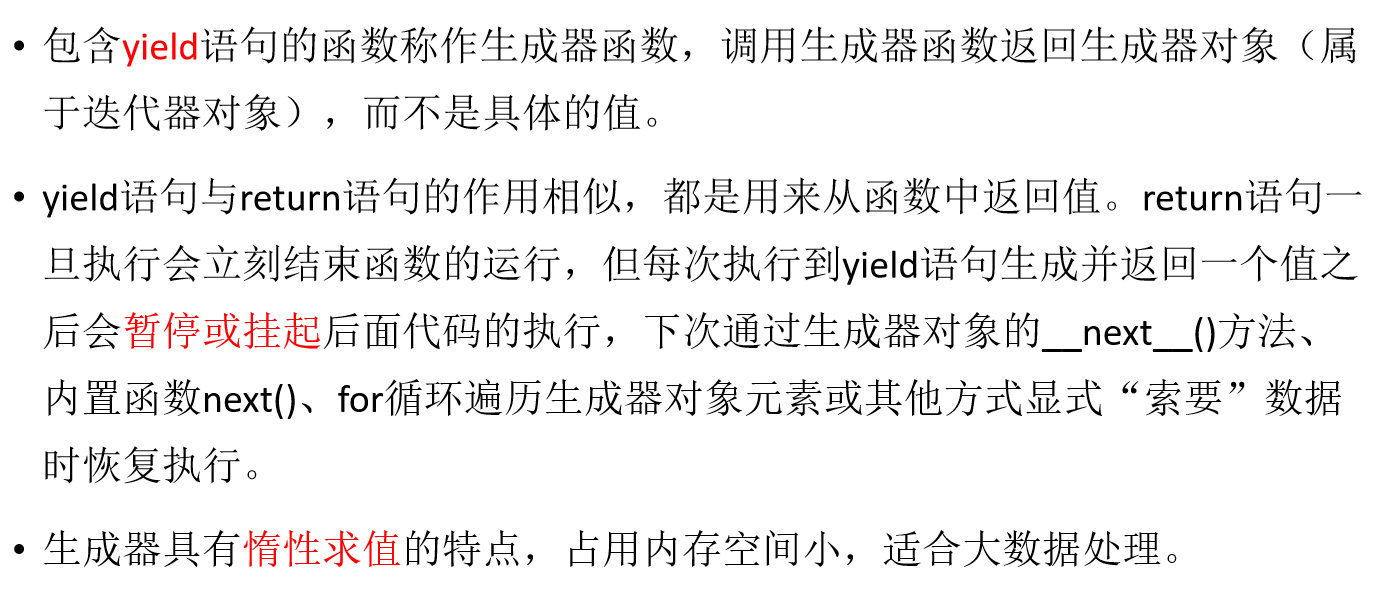

In [18]:
def f():
    a, b = 1, 1            #序列解包，同时为多个元素赋值
    while True:
        yield a            #暂停执行，需要时再产生一个新元素
        a, b = b, a+b      #序列解包，继续生成新元素

a = f()   #创建生成器对象

next(a)

1

In [20]:
a.__next__()

2

In [26]:
for i in range(10):    #斐波那契数列中前10个元素
    print(a.__next__(), end=' ')


2 3 5 8 13 21 34 55 89 144 

In [28]:
def f():
    yield from 'abcdefg'        #使用yield表达式创建生成器

In [25]:
def f():
    for char in 'abcdefg':
        yield char

In [26]:
x = f()
x

<generator object f at 0x000001662608EF90>

In [30]:
next(x)

'a'

In [31]:
for item in x:              #输出x中的剩余元素
    print(item, end=' ')

b c d e f g 

In [74]:
c = [1,2,3]
a = (i for i in c)
a

<generator object <genexpr> at 0x000001F452A043C0>

In [75]:
next(a)

1

In [32]:
def gen():
    yield 1
    yield 2
    yield 3
a,b,c = gen() #生成器对象支持序列解包
a,b,c

(1, 2, 3)

## 生成器（Generator）是一种 惰性计算 的可迭代对象，它会按需生成值。但在解包时，Python 仍然要求 变量数量必须匹配生成器能产生的值的数量。

In [21]:
def f():
    yield from 'abcdefg'
    
    
a,b,c,d,e,f,g=f()
a,b,c

('a', 'b', 'c')

# 5.6  精彩案例赏析



# 示例5-1  编写函数，接收任意多个实数，返回一个元组，其中第一个元素为所有参数的平均值，其他元素为所有参数中大于平均值的实数。


In [86]:
def demo(*para):
    avg = sum(para)/len(para)
    c = [i for i in para if i>avg]
    return (avg,)+tuple(c)

In [87]:
demo(1,2,3,5)

(2.75, 3, 5)

# 示例5-2  编写函数，接收字符串参数，返回一个元组，其中第一个元素为大写字母个数，第二个元素为小写字母个数。


In [34]:
def demo(s):
    result = [0, 0]
    for ch in s:
        if ch.islower():
            result[1] += 1
        elif ch.isupper():
            result[0] += 1
    return tuple(result)


In [35]:
demo('anDsFe')

(2, 4)

# 示例5-3  编写函数，接收包含n个整数的列表lst和一个整数k（0<=k<n）作为参数，返回新列表。处理规则为：将列表lst中下标k之前的元素逆序，下标k之后的元素逆序，然后将整个列表lst中的所有元素逆序。


In [ ]:
def demo(lst, k):
    x = lst[:k]
    x.reverse()
    y = lst[k:]
    y.reverse()
    return list(reversed(x+y))

print(demo([1, 2, 3, 4, 5, 6, 7], 3))

In [90]:
def demo(lst, k):
    return lst[k:] + lst[:k]

## 示例5-6  编写函数，接收一个正偶数为参数，输出两个素数，并且这两个素数之和等于原来的正偶数。如果存在多组符合条件的素数，则全部输出。

In [31]:
def demo(n):
    def isPrime(p):
        if p == 2:
            return True
        if p%2 == 0:
            return False
        for i in range(3, int(p**0.5)+1, 2):
            if p%i == 0:
                return False
        return True
    
    if isinstance(n, int) and n>0 and n%2==0:
        for i in range(2, n//2+1):
            if isPrime(i) and isPrime(n-i):
                print(i, '+', n-i, '=', n)

demo(4)

2 + 2 = 4


# 示例5-8  编写函数，接收一个所有元素值都不相等的整数列表x和一个整数n，要求将值为n的元素作为支点，将列表中所有值小于n的元素全部放到n的前面，所有值大于n的元素放到n的后面。


In [105]:
def demo(x, n):
    t1 = [i for i in x if i<n]
    t2 = [i for i in x if i>n]
    return t1 + [n] + t2

# 示例5-12  编写函数，计算形式如a+aa+aaa+aaaa+...+aaa...aaa的表达式的值，其中a为小于10的自然数。



In [37]:
def demo(a, n):
    assert type(n)==int and type(a)==int and 0<a<10, 'n must be int; a must be integer between 1 and 9'
    result, t = 0, 0
    for i in range(n):
        t = t*10 + a
        result += t
    return result

print(demo(3, 4))

3702


# 示例5-15  编写函数计算任意位数的黑洞数。黑洞数是指这样的整数：由这个数字每位上的数字组成的最大数减去每位数字组成的最小数仍然得到这个数自身。例如3位黑洞数是495，因为954-459=495，4位数字是6174，因为7641-1467=6174。


In [106]:
def main(n):
    '''参数n表示数字的位数，例如n=3时返回495，n=4时返回6174'''
    #待测试数范围的起点和结束值
    start = 10**(n-1)
    end = 10**n
    #依次测试每个数
    for i in range(start, end):
        #由这几个数字组成的最大数和最小数
        big = ''.join(sorted(str(i),reverse=True))
        little = ''.join(reversed(big))
        big, little = map(int,(big, little))
        if big-little == i:
            print(i)
n = 4
main(n)


6174


# 示例5-17  编写函数，查找序列元素的最大值和最小值。给定一个序列，返回一个元组，其中元组第一个元素为序列最大值，第二个元素为序列最小值。


In [118]:
def myMaxMin(iterable):
    '''返回序列的最大值和最小值'''
    tMax = tMin = iterable[0]
    for item in iterable[1:]:
        if item > tMax:
            tMax = item
        elif item < tMin:
            tMin = item
            
    return (tMax, tMin)


myMaxMin('abcde')
myMaxMin([1,2,3,4,8])

(8, 1)

In [121]:
def myMaxMin(iterable):
    tMax = max(iterable)
    tMin = min(iterable)
    return (tMax, tMin)

myMaxMin('abcde')
myMaxMin([1,2,3,4,8])

(8, 1)

# 示例5-18  编写函数，模拟内置函数all()、any()和zip()。




In [ ]:
def myAll(iterable):
    '''模拟内置函数all()'''
    #只要有一个元素等价于False，返回False
    for item in iterable:
        if not item:
            return False
    #如果所有元素都等价于True，返回True
    return True

In [ ]:
def myAny(iterable):
    '''模拟内置函数any()'''
    #只要有一个元素等价于True，返回True
    for item in iterable:
        if item:
            return True
    #如果所有元素都等价于False，返回False
    return False


In [125]:
def myZip(*iterables):
    '''模拟内置函数zip()'''
    #获取所有迭代对象的最小长度
    min_length = min(map(len,iterables))
    
    #依次返回所有迭代对象中对应位置上元素组成的元组
    for i in range(min_length):
        yield tuple((it[i] for it in iterables))

        
a = myZip('abcd',[1,2,3])        

In [126]:
next(a)

('a', 1)

In [1]:
iterables=([1,2,3],'abcde')
for i in range(3):
    a=[it[i] for it in iterables]
    print(a)

[1, 'a']
[2, 'b']
[3, 'c']


In [6]:
def demo(a, *b, **c):
    c[a]=b
    return c


demo(3,2,b=1)

{'b': 1, 3: (2,)}

In [ ]:
实现一个函数main，它接收一个包含若干字符串的列表lst和一个正则表达式pattern，返回一个包含匹配正则表达式的字符串及其索引的元组列表。例如，
lst为['apple', 'banana', 'cherry']和pattern为 r'a.*' 时，返回 [(0, 'apple'), (1, 'banana')]。

In [31]:
import re
data = 'apple banana cherry'
re.match(r'a.*','apple')

<re.Match object; span=(0, 5), match='apple'>

In [29]:
import re

def main(lst, pattern):
    s = re.findall(pattern,lst)
    print(s)
    return list(enumerate(s))
# 测试代码
data = 'apple banana cherry'
pattern = 'a.*'
result = main(data, pattern)
print(result) 

['apple banana cherry']
[(0, 'apple banana cherry')]


In [42]:
class temple:
    def __init__(self,a,b):
        self.a =a
        self.b =b       
    def __add__(self,another):
        return self.a+another.b
e1 = temple(2,3)
e2 = temple(3,4)
e1+e2

6